In [65]:
#Code adpated from the STAR package https://github.com/xihaoli/STAAR/blob/dc4f7e509f4fa2fb8594de48662bbd06a163108c/R/CCT.R wtih a modifitcaiton: when indiviudal p-value = 1, use minimum p-value 
#' An analytical p-value combination method using the Cauchy distribution
#'
#' The \code{CCT} function takes in a numeric vector of p-values, a numeric
#' vector of non-negative weights, and return the aggregated p-value using Cauchy method.
#' @param pvals a numeric vector of p-values, where each of the element is
#' between 0 to 1, to be combined.
#' @param weights a numeric vector of non-negative weights. If \code{NULL}, the
#' equal weights are assumed.
#' @return the aggregated p-value combining p-values from the vector \code{pvals}.
#' @examples pvalues <- c(2e-02,4e-04,0.2,0.1,0.8)
#' @examples CCT(pvals=pvalues)
#' @references Liu, Y., & Xie, J. (2020). Cauchy combination test: a powerful test
#' with analytic p-value calculation under arbitrary dependency structures.
#' \emph{Journal of the American Statistical Association 115}(529), 393-402.
#' (\href{https://www.tandfonline.com/doi/full/10.1080/01621459.2018.1554485}{pub})
#' @export

CCT <- function(pvals, weights=NULL){
  #### check if there is NA
  if(sum(is.na(pvals)) > 0){
    stop("Cannot have NAs in the p-values!")
  }

  #### check if all p-values are between 0 and 1
  if((sum(pvals<0) + sum(pvals>1)) > 0){
    stop("All p-values must be between 0 and 1!")
  }

  #### check if there are p-values that are either exactly 0 or 1.
  is.zero <- (sum(pvals==0)>=1)
  is.one <- (sum(pvals==1)>=1)
  #if(is.zero && is.one){
  #  stop("Cannot have both 0 and 1 p-values!")
  #}
  if(is.zero){
    return(0)
  }
  if(is.one){
    #warning("There are p-values that are exactly 1!")
    return(min(1,(min(pvals))*(length(pvals))))
  }

  #### check the validity of weights (default: equal weights) and standardize them.
  if(is.null(weights)){
    weights <- rep(1/length(pvals),length(pvals))
  }else if(length(weights)!=length(pvals)){
    stop("The length of weights should be the same as that of the p-values!")
  }else if(sum(weights < 0) > 0){
    stop("All the weights must be positive!")
  }else{
    weights <- weights/sum(weights)
  }

  #### check if there are very small non-zero p-values
  is.small <- (pvals < 1e-16)
  if (sum(is.small) == 0){
    cct.stat <- sum(weights*tan((0.5-pvals)*pi))
  }else{
    cct.stat <- sum((weights[is.small]/pvals[is.small])/pi)
    cct.stat <- cct.stat + sum(weights[!is.small]*tan((0.5-pvals[!is.small])*pi))
  }

  #### check if the test statistic is very large.
  if(cct.stat > 1e+15){
    pval <- (1/cct.stat)/pi
  }else{
    pval <- 1-pcauchy(cct.stat)
  }
  return(pval)
}

In [66]:
get_CCT_pvalue = function(pvalue, weights=NULL){
   pvals = pvalue
   notna = which(!is.na(pvals))
   if(length(notna) > 0){
     pvals = pvals[!is.na(pvals)]
     cctpval = CCT(pvals, weights=weights)
   }else{
     cctpval = NA
   }
   return(cctpval)
}

In [67]:
library(data.table)
library(dplyr)
library(ggplot2)
library(qvalue)

In [68]:
mydir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/ct_mean_expression_files/'
df_all = read.csv(paste0(mydir,'mean_expression_all_genes_all_celltypes.csv'), row.names = 1)
df_all$mean_overall = rowMeans(df_all[,3:20])

In [69]:
saige_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'
celltypes = list.files(saige_dir)
celltypes = celltypes[!(celltypes %in% c('README.md','CD4_TCM_sample_perm0','annotate','coloc_results'))]
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [70]:
df_list = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    rare_egenes = df[df$qvalue<0.05,]$Region
    nonrare_egenes = df$Region[!(df$Region %in% rare_egenes)]
    df_cur = data.frame(celltype = celltype,
                        test =  c('rare eGene','non rare eGene'),
                         mean_overall = c(mean(df_all[df_all$gene %in% rare_egenes,'mean_overall']), 
                                        mean(df_all[df_all$gene %in% nonrare_egenes,'mean_overall'])))
    df_list[[celltype]] = df_cur
}
df_to_plot = rbindlist(df_list)
nrow(df_to_plot)
head(df_to_plot,2)

[1] 56

celltype,test,mean_overall
<chr>,<chr>,<dbl>
ASDC,rare eGene,0.8024160
ASDC,non rare eGene,0.6487655


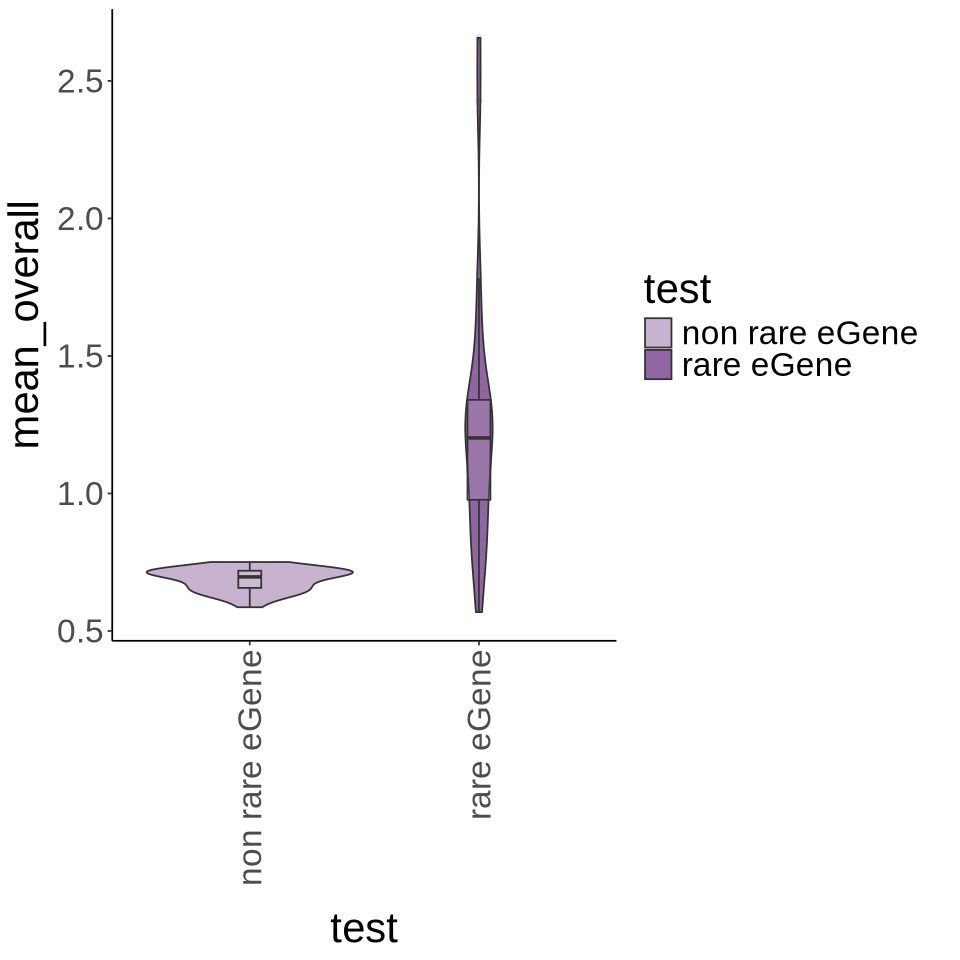

In [71]:
options(repr.plot.width = 8, repr.plot.height = 8)
p = ggplot(df_to_plot, aes(x=test,y=mean_overall,fill=test)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.1)
p = p + theme_classic() 
p = p + scale_fill_manual(values=c('#C7B2D0','#9066A2'))
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

In [72]:
rare_egenes = c()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    for (i in 1:nrow(df)){
        df[i,'Pvalue_noACAT'] = get_CCT_pvalue(c(df[i,'Pvalue_Burden'], df[i,'Pvalue_SKAT']))
    }
    df$qvalue = qvalue(df$Pvalue_noACAT)$qvalues
    rare_egenes = c(rare_egenes,df[df$qvalue<0.05,]$Region)
}
rare_egenes = unique(rare_egenes)

In [73]:
# ?ifelse

In [74]:
df_to_plot1 = df_all
df_to_plot1 = df_to_plot1 %>% mutate(is_rare = ifelse(gene %in% rare_egenes, 'yes','no'))
head(df_to_plot1)

,gene,chrom,mean_ASDC,mean_B_intermediate,mean_B_memory,mean_B_naive,mean_CD14_Mono,mean_CD16_Mono,mean_CD4_CTL,mean_CD4_Naive,⋯,mean_ILC,mean_MAIT,mean_NK,mean_NK_CD56bright,mean_NK_Proliferating,mean_pDC,mean_Plasmablast,mean_Treg,mean_overall,is_rare
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,ENSG00000000419,20,1.088235294,0.437610368,0.422526797,0.351859479,0.53241572,0.581129175,0.35086813,0.385559781,⋯,0.3084990,0.37698007,0.35631074,0.39692601,0.64855044,0.79549680,1.146938047,0.359868768,0.59313372,yes
3,ENSG00000000457,1,0.194117647,0.088578612,0.105482346,0.083423816,0.12189993,0.171435621,0.09576565,0.100984136,⋯,0.1605855,0.10416164,0.08793871,0.15396885,0.14951681,0.49669490,0.263702910,0.108198616,0.13313541,yes
4,ENSG00000000460,1,0.169747899,0.203473407,0.197968796,0.384692529,0.06810105,0.121553778,0.07090532,0.305734666,⋯,0.2407691,0.04287916,0.09197385,0.45877869,0.33181291,0.26048337,0.090519550,0.492537440,0.23385711,yes
5,ENSG00000000938,1,1.477310924,0.419285565,0.134868136,0.151841828,3.52552416,3.697425239,0.16924481,0.006491294,⋯,0.1944505,0.04862672,0.51768694,0.57020051,0.52354078,0.03687255,0.252097840,0.007250072,0.82340040,yes
6,ENSG00000000971,1,0.004201681,0.001638682,0.001567127,0.001412059,0.00458806,0.002220767,0.39832485,0.001407971,⋯,0.2010050,0.38621887,0.02718688,0.01294639,0.03594898,0.00185912,0.002499554,0.002099376,0.06643801,no
7,ENSG00000001036,6,0.331932773,0.100199036,0.082997108,0.041936554,0.43056534,0.459252721,0.05574637,0.041011121,⋯,0.1577452,0.07183049,0.09564457,0.17068523,0.21870893,0.11764098,0.352079986,0.060439934,0.19778525,yes


Warning message:
“Removed 1049 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 1049 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


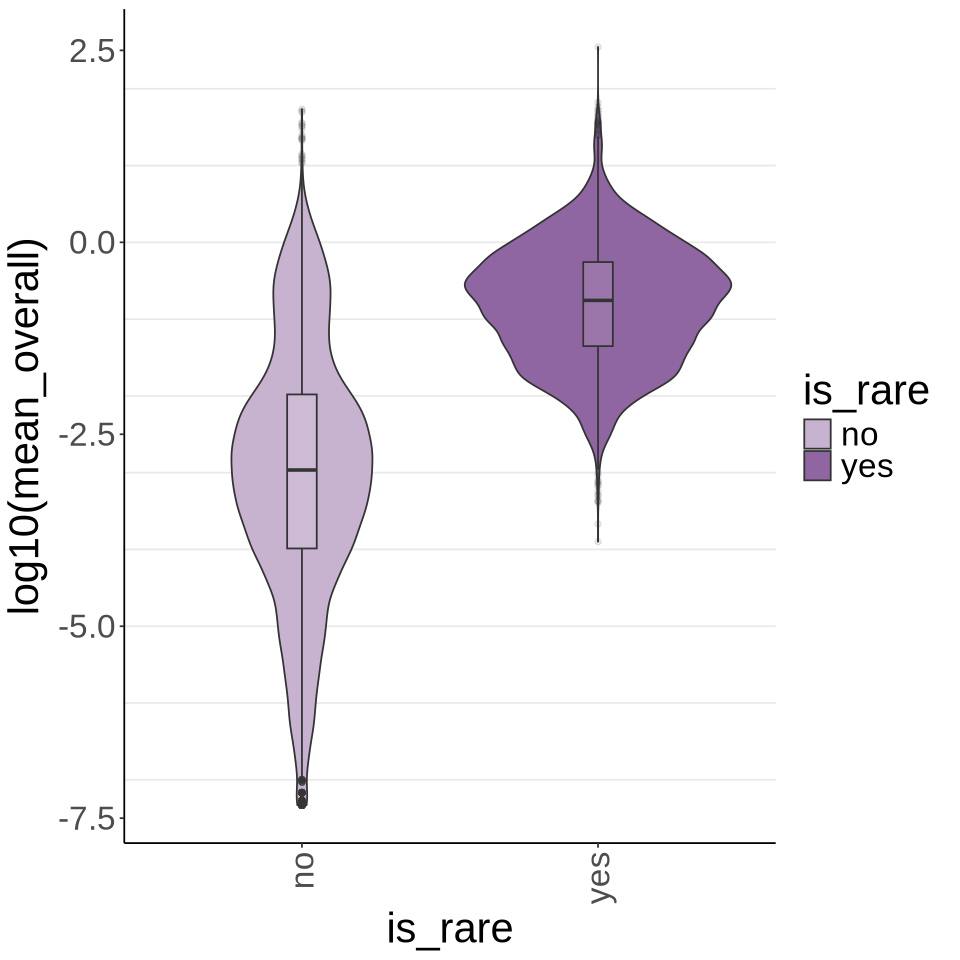

In [100]:
options(repr.plot.width = 8, repr.plot.height = 8)
p = ggplot(df_to_plot1, aes(x=is_rare,y=log10(mean_overall),fill=is_rare)) 
p = p + geom_hline(yintercept = c(log10(1e-7),log10(1e-6),log10(1e-5),log10(1e-4),log10(1e-3),log10(1e-2),
                                  log10(1e-1),log10(1),log10(10^1),log10(10^2)), col='lightgrey', alpha=0.5)
p = p + geom_violin() + geom_boxplot(width=0.1, fill='white', alpha=0.1)
p = p + theme_classic()# + ylim(c(0,20))
p = p + scale_fill_manual(values=c('#C7B2D0','#9066A2'))
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p

In [64]:
x=200
log10(x)

[1] 2.30103

In [94]:
specific_file = '/directflow/SCCGGroupShare/projects/albhen/tenk10k-explore/results/tenk10k_phase1/common_eqtl_pairwise_scenario_table_v2_labelled.tsv'
df0 = read.csv(specific_file,sep='\t')
nrow(df0)
head(df0,2)

[1] 154932

,celltype,gene,MarkerID,n_expressed,n_egene,beta,se,pval,CD4_TCM,CD4_Naive,⋯,B_memory,Plasmablast,CD14_Mono,CD16_Mono,cDC2,pDC,cDC1,HSPC,ASDC,aggregated_score
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,ASDC,ENSG00000020633,1:24970252:A:C,28,14,-0.213571,0.0492147,1.42751e-05,3,3,⋯,2,3,3,2,3,2,2,2,NA,3
2,ASDC,ENSG00000049247,1:7913587:T:TTTTTTGTTGTTGTTG,14,14,6.878290,0.8824930,6.48378e-15,1,1,⋯,1,1,1,1,3,1,1,1,NA,4


In [95]:
head(df_all)

,gene,chrom,mean_ASDC,mean_B_intermediate,mean_B_memory,mean_B_naive,mean_CD14_Mono,mean_CD16_Mono,mean_CD4_CTL,mean_CD4_Naive,⋯,mean_HSPC,mean_ILC,mean_MAIT,mean_NK,mean_NK_CD56bright,mean_NK_Proliferating,mean_pDC,mean_Plasmablast,mean_Treg,mean_overall
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,ENSG00000000419,20,1.088235294,0.437610368,0.422526797,0.351859479,0.53241572,0.581129175,0.35086813,0.385559781,⋯,0.93288591,0.3084990,0.37698007,0.35631074,0.39692601,0.64855044,0.79549680,1.146938047,0.359868768,0.59313372
3,ENSG00000000457,1,0.194117647,0.088578612,0.105482346,0.083423816,0.12189993,0.171435621,0.09576565,0.100984136,⋯,0.26013423,0.1605855,0.10416164,0.08793871,0.15396885,0.14951681,0.49669490,0.263702910,0.108198616,0.13313541
4,ENSG00000000460,1,0.169747899,0.203473407,0.197968796,0.384692529,0.06810105,0.121553778,0.07090532,0.305734666,⋯,0.22228188,0.2407691,0.04287916,0.09197385,0.45877869,0.33181291,0.26048337,0.090519550,0.492537440,0.23385711
5,ENSG00000000938,1,1.477310924,0.419285565,0.134868136,0.151841828,3.52552416,3.697425239,0.16924481,0.006491294,⋯,0.08026846,0.1944505,0.04862672,0.51768694,0.57020051,0.52354078,0.03687255,0.252097840,0.007250072,0.82340040
6,ENSG00000000971,1,0.004201681,0.001638682,0.001567127,0.001412059,0.00458806,0.002220767,0.39832485,0.001407971,⋯,0.37208054,0.2010050,0.38621887,0.02718688,0.01294639,0.03594898,0.00185912,0.002499554,0.002099376,0.06643801
7,ENSG00000001036,6,0.331932773,0.100199036,0.082997108,0.041936554,0.43056534,0.459252721,0.05574637,0.041011121,⋯,0.22577181,0.1577452,0.07183049,0.09564457,0.17068523,0.21870893,0.11764098,0.352079986,0.060439934,0.19778525


In [96]:
df_to_plot2 = inner_join(df0,df_all)
head(df_to_plot2)

Joining with `by = join_by(gene)`


,celltype,gene,MarkerID,n_expressed,n_egene,beta,se,pval,CD4_TCM,CD4_Naive,⋯,mean_HSPC,mean_ILC,mean_MAIT,mean_NK,mean_NK_CD56bright,mean_NK_Proliferating,mean_pDC,mean_Plasmablast,mean_Treg,mean_overall
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ASDC,ENSG00000020633,1:24970252:A:C,28,14,-0.2135710,0.0492147,1.42751e-05,3,3,⋯,1.266577181,1.3707669,2.28139798,2.92830428,4.19021874,3.38160031,0.305412105,0.897875379,0.84360073,1.43654230
2,ASDC,ENSG00000049247,1:7913587:T:TTTTTTGTTGTTGTTG,14,14,6.8782900,0.8824930,6.48378e-15,1,1,⋯,0.005637584,0.0362683,0.03285112,0.03932976,0.04780843,0.04035562,0.006920058,0.004820568,0.05596920,0.01592711
3,ASDC,ENSG00000116288,1:8065826:C:CT,28,26,0.0824164,0.0184997,8.38885e-06,3,3,⋯,2.376644295,0.7708106,0.94653568,1.02730248,1.12654321,2.34000773,6.186841562,2.850205320,0.88195896,2.24610617
4,ASDC,ENSG00000117091,1:160705479:G:C,28,22,0.2521050,0.0317404,1.97810e-15,3,3,⋯,0.212617450,1.4024470,2.49192186,1.28531966,1.33534261,1.20842675,0.770501962,4.323156579,1.75587740,3.11701269
5,ASDC,ENSG00000117394,1:42971584:CA:C,27,10,0.4078080,0.0787655,2.24877e-07,3,2,⋯,0.228724832,0.1022504,0.13112593,0.16921749,0.09690115,0.23022806,0.831129932,0.283342260,0.07835688,0.23045211
6,ASDC,ENSG00000117632,1:25972262:A:AT,28,15,-0.4283170,0.0651511,4.89130e-11,3,3,⋯,3.385234899,0.1024689,0.11927798,0.15170175,0.08020549,10.51302667,2.895682710,0.577218354,0.10960953,1.71819447


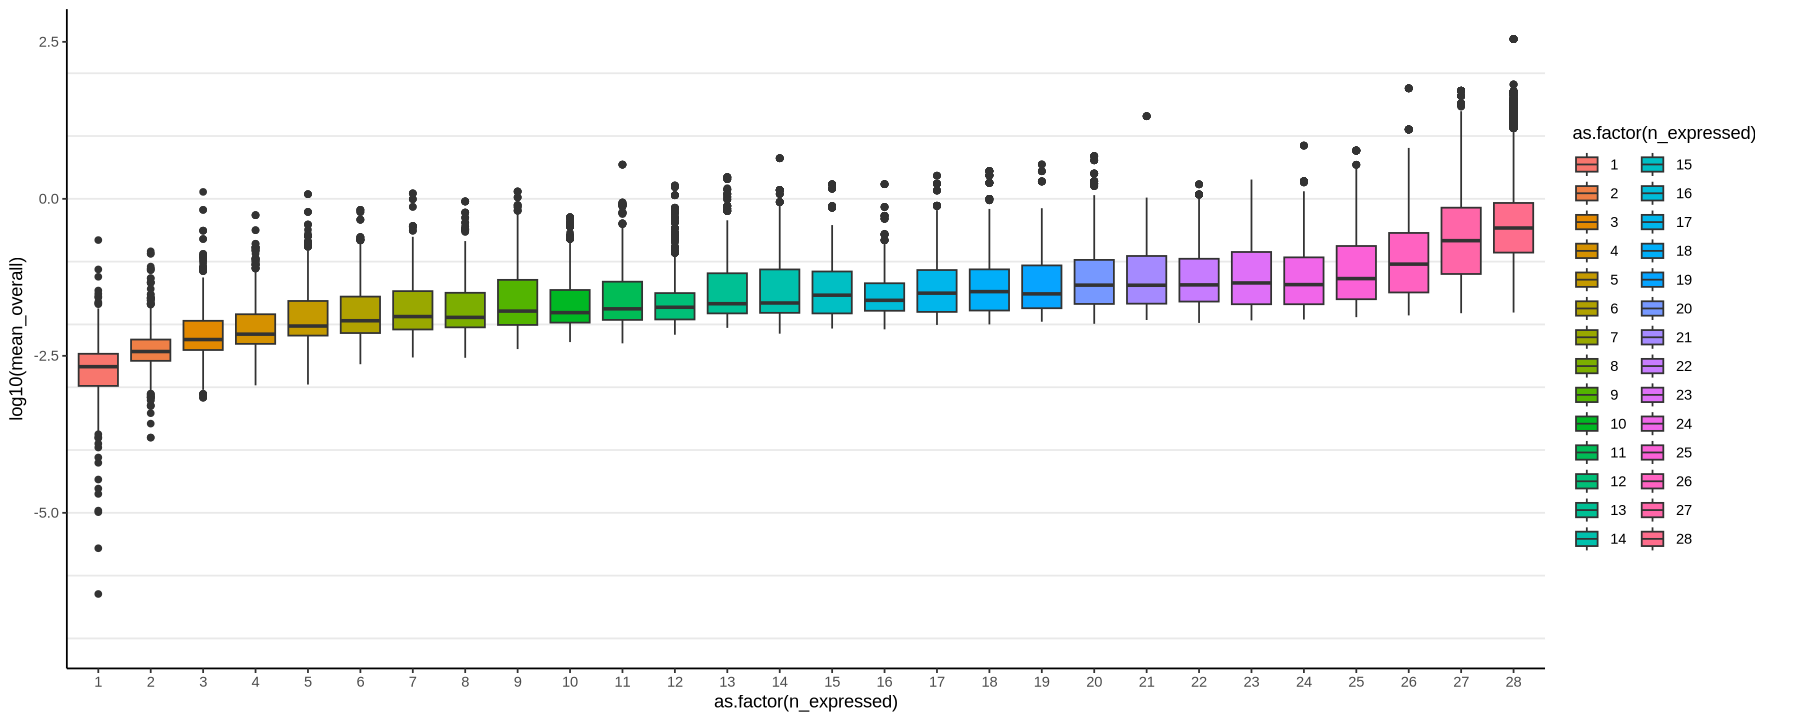

In [99]:
options(repr.plot.width = 15, repr.plot.height = 6)
p = ggplot(df_to_plot2, aes(x=as.factor(n_expressed), y=log10(mean_overall), fill=as.factor(n_expressed)))
p = p + geom_hline(yintercept = c(log10(1e-7),log10(1e-6),log10(1e-5),log10(1e-4),log10(1e-3),log10(1e-2),
                                  log10(1e-1),log10(1),log10(10^1),log10(10^2)), col='lightgrey', alpha=0.5)
p = p + geom_boxplot() + theme_classic()
p